In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(seed=42)

In [2]:
def get_angle(v1, v2, v3):
    dot = np.dot(v1-v2, v1-v3)
    cross = ((v1-v2)[0])*((v1-v3)[1]) - ((v1-v2)[1])*((v1-v3)[0])
    return np.arctan2(cross, dot)

In [3]:
def get_grads(j, dist, angle, h=1e-4): #Gets del(Ej)/del(xk) over k
    v = np.zeros((6, 2))
    grad = np.zeros((6, 2))
    v[0] = np.zeros(2)
    v[1] = np.array([dist[0]*np.cos(angle[0]), dist[0]*np.sin(angle[0])])
    v[2] = np.array([dist[1]*np.cos(angle[1]), dist[1]*np.sin(angle[1])])
    v[3] = np.array([dist[2]*np.cos(angle[2]), dist[2]*np.sin(angle[2])])
    v[4] = np.array([dist[3]*np.cos(angle[3]), dist[3]*np.sin(angle[3])])
    v[5] = np.array([dist[4]*np.cos(angle[4]), dist[4]*np.sin(angle[4])])
    for i in range(1, 6):
        v[i, 0] = v[i, 0] + h
        Epx = get_energy(v, thetareq[j])
        v[i, 0] = v[i, 0] - 2*h
        Emx = get_energy(v, thetareq[j])
        v[i, 0] = v[i, 0] + h
        v[i, 1] = v[i, 1] + h
        Epy = get_energy(v, thetareq[j])
        v[i, 1] = v[i, 1] - 2*h
        Emy = get_energy(v, thetareq[j])
        v[i, 1] = v[i, 1] + h
        
        grad[i, :] = np.array([(Epx-Emx)/(2*h), (Epy-Emy)/(2*h)]) #del(Ej)/del(vi) = del(Ej)/del(xi)
        
    grad[0, :] = -(grad[1, :] + grad[2, :] + grad[3, :] + grad[4, :] + grad[5, :]) #del(Ej)/del(xj) = -sum(del(Ej)/del(vk))
    return grad

In [4]:
def get_new_grads(j, angle, thetareq, distreq, h=1e-4):
    dist = distreq[j]
    v = np.zeros((6, 2))
    grad = np.zeros((6, 2))
    v[0] = np.zeros(2)
    v[1] = np.array([dist[0]*np.cos(angle[0]), dist[0]*np.sin(angle[0])])
    v[2] = np.array([dist[1]*np.cos(angle[1]), dist[1]*np.sin(angle[1])])
    v[3] = np.array([dist[2]*np.cos(angle[2]), dist[2]*np.sin(angle[2])])
    v[4] = np.array([dist[3]*np.cos(angle[3]), dist[3]*np.sin(angle[3])])
    v[5] = np.array([dist[4]*np.cos(angle[4]), dist[4]*np.sin(angle[4])])
    '''
    for i in range(2, 6):
        test_v = v[i]/np.linalg.norm(v[i])
        grad[i, 0] = -test_v[1]
        grad[i, 1] = test_v[0]
        grad[i, :] = h*np.sin(((angle[i-1] - angle[0])%360)*2*np.pi - thetareq[j, i-2])*grad[i, :]
    test_v = v[1]/np.linalg.norm(v[1])
    grad[1, 0] = -test_v[1]
    grad[1, 1] = test_v[0]
    adder = 0
    for i in range(2, 6):
        adder = adder - h*np.sin(((angle[i-1] - angle[0])%360)*2*np.pi - thetareq[j, i-2])
    grad[1, :] = grad[1, :]*adder
    '''
    for i in range(1, 6):
        v[i, 0] = v[i, 0] + h
        Epx = get_energy(v, thetareq[j])
        v[i, 0] = v[i, 0] - 2*h
        Emx = get_energy(v, thetareq[j])
        v[i, 0] = v[i, 0] + h
        v[i, 1] = v[i, 1] + h
        Epy = get_energy(v, thetareq[j])
        v[i, 1] = v[i, 1] - 2*h
        Emy = get_energy(v, thetareq[j])
        v[i, 1] = v[i, 1] + h
        
        grad[i, :] = np.array([(Epx-Emx)/(2*h), (Epy-Emy)/(2*h)]) #del(Ej)/del(vi) = del(Ej)/del(xi)
        
    grad[0, :] = -(grad[1, :] + grad[2, :] + grad[3, :] + grad[4, :] + grad[5, :]) #del(Ej)/del(xj) = -sum(del(Ej)/del(vk))
    return grad

In [5]:
def get_energy(vec, reqd_angles):
    angle1 = get_angle(vec[0], vec[1], vec[2])
    angle2 = get_angle(vec[0], vec[1], vec[3])
    angle3 = get_angle(vec[0], vec[1], vec[4])
    angle4 = get_angle(vec[0], vec[1], vec[5])
    E = 4 - np.cos(angle1 - reqd_angles[0]) - np.cos(angle2 - reqd_angles[1]) - np.cos(angle3 - reqd_angles[2]) - np.cos(angle4 - reqd_angles[3]) + 0.01*((1/np.linalg.norm(vec[1] - vec[0])) + (1/np.linalg.norm(vec[2] - vec[0])) + (1/np.linalg.norm(vec[3] - vec[0])) + (1/np.linalg.norm(vec[4] - vec[0])) + (1/np.linalg.norm(vec[5] - vec[0])))
    return E

In [10]:
def evolve(positions, thetareq, distreq, alpha = 1e-3):
    E = 0
    grads = np.zeros(np.shape(positions))
    for i in range(6): #Decides which bot is in the active phase currently
        v1 = positions[i]
        v2 = positions[(i+1)%6]
        v3 = positions[(i+2)%6]
        v4 = positions[(i+3)%6]
        v5 = positions[(i+4)%6]
        v6 = positions[(i+5)%6]
        ref = np.array([1, 0])
        dist = np.array([np.linalg.norm(v1-v2), np.linalg.norm(v1-v3), np.linalg.norm(v1-v4), np.linalg.norm(v1-v5), np.linalg.norm(v1-v6)]) #Gets perfect distance data. The bot does this using distance data frm intensity values
        angle = np.array([get_angle(v1, v1+ref, v2), get_angle(v1, v1+ref, v3), get_angle(v1, v1+ref, v4), get_angle(v1, v1+ref, v5), get_angle(v1, v1+ref, v6)]) + rng.normal(loc=0.0, scale=1.0/360, size=5)*2*np.pi#Gets im-perfect angle data. The bot does this using bearing data from IR detectors
        
        #diff = np.roll(get_grads(i, dist, angle), i , axis=0) #Gets grads corresponding to Ei, rolls the matrix to ensure bot-wise gradient ordering
        diff = np.roll(get_new_grads(i, angle, thetareq, distreq), i, axis=0)
        
        grads = grads + diff
        E2 = get_energy(np.array([v1, v2, v3, v4, v5, v6]), thetareq[i]) #Gets energy of the current configuration wrt bot i
        #E.append(diff)
        E = E + E2

    noise = np.random.normal(loc=0.0, scale=0.05, size=(6, 2))
    new_positions = positions - alpha*grads + noise 
    return new_positions, E, grads

In [7]:
def total_energy(positions, thetareqd):
    E = 0
    for i in range(6):
        E = E + get_energy(np.roll(positions, -i, axis = 0), thetareqd[i])
    return E

Firstly, lets try to form a hexagon

In [11]:
thetareq1 = np.array([30, 60, 90, 120])*(np.pi/180)
thetareq2 = np.array([30, 60, 90, 120])*(np.pi/180)
thetareq3 = np.array([30, 60, 90, 120])*(np.pi/180)
thetareq4 = np.array([30, 60, 90, 120])*(np.pi/180)
thetareq5 = np.array([30, 60, 90, 120])*(np.pi/180)
thetareq6 = np.array([30, 60, 90, 120])*(np.pi/180)
thetareq = np.array([thetareq1, thetareq2, thetareq3, thetareq4, thetareq5, thetareq6])

distreq1 = np.array([5, 5*np.sqrt(3), 10, 5*np.sqrt(3), 5])
distreq2 = np.array([5, 5*np.sqrt(3), 10, 5*np.sqrt(3), 5])
distreq3 = np.array([5, 5*np.sqrt(3), 10, 5*np.sqrt(3), 5])
distreq4 = np.array([5, 5*np.sqrt(3), 10, 5*np.sqrt(3), 5])
distreq5 = np.array([5, 5*np.sqrt(3), 10, 5*np.sqrt(3), 5])
distreq6 = np.array([5, 5*np.sqrt(3), 10, 5*np.sqrt(3), 5])
distreq = np.array([distreq1, distreq2, distreq3, distreq4, distreq5, distreq6])

positions = np.random.randn(6, 2) * 2

In [12]:
E = 30
step = 0
while E > 0.15:
    positions, E, grads = evolve(positions, thetareq, distreq)
    if step%10 ==0:
        print(E)
plt.scatter(positions[:, 0], positions[:, 1], color = 'red', s = 5)
plt.show()

20.344985951065233
20.73570889611379
20.864538023243433
21.17016099399204
21.254473915266157
21.379177070250954
21.079621757843995
21.00348728842756
21.10663823061547
20.9820620587991
21.22768206321378
21.303772319112987
21.41698486487718
21.442206646202365
21.265765543778436
21.203682141695335
21.061949873087922
20.741724632280565
20.48305717912229
20.703085196667015
20.77831371062949
20.802314140814417
21.04539511996746
20.873380412395342
20.71782905207826
20.625118560582553
20.532044898995622
20.426787627974285
20.326963288577122
20.261330898647053
20.075745258714214
20.06128481345752
20.11627772332062
19.936832524200938
20.14720951782004
20.073928618279645
19.893655190224564
20.029579478578185
19.95489927187426
19.638225679252432
19.750495547689695
19.617550953499862
19.915975670581172
19.916797669068934
20.112049091658864
20.07944084953759
20.100454699859675
20.221233018008192
20.159963550469776
19.845803024558155
19.753340992323977
19.62875372416439
19.725354891252035
19.49229511

KeyboardInterrupt: 

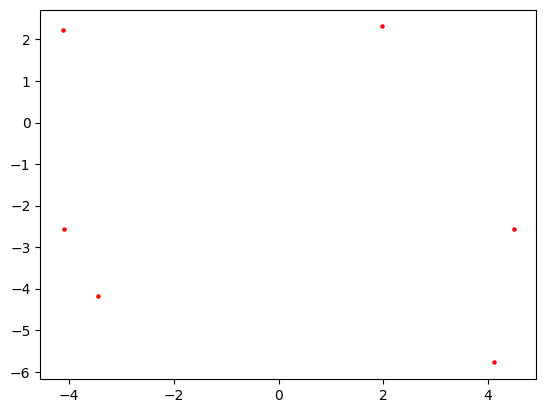

In [13]:
plt.scatter(positions[:, 0], positions[:, 1], color = 'red', s = 5)
plt.show()

In [10]:
print(np.linalg.norm(positions[0] - positions[1]))
print(np.linalg.norm(positions[1] - positions[2]))
print(np.linalg.norm(positions[2] - positions[3]))
print(np.linalg.norm(positions[3] - positions[4]))
print(np.linalg.norm(positions[4] - positions[5]))
print(np.linalg.norm(positions[5] - positions[0]))

1.7582401346102756
1.6502116009224828
2.0489810587926134
1.4167712510199413
2.0164117116658917
1.733564731857107


Stuff required to be added:
1. Accounting for measurement noise and errors
2. Realistic step sizes based on limitations on Vibration motors
3. Other shapes

Let's try a boat shape this time

In [36]:
positions = np.zeros((6,2))
positions[0, :] = np.array([0, 0])
positions[1, :] = np.array([5, 0])
positions[2, :] = np.array([5, 5])
positions[3, :] = np.array([10/3, 5/2])
positions[4, :] = np.array([5/3, 5/2])
positions[5, :] = np.array([0, 5])
for i in range(6):
    thetareq[i, :] = np.array([get_angle(positions[i, :], positions[(i+1)%6, :], positions[(i+2)%6, :]), get_angle(positions[i, :], positions[(i+1)%6, :], positions[(i+3)%6, :]), get_angle(positions[i, :], positions[(i+1)%6, :], positions[(i+4)%6, :]), get_angle(positions[i, :], positions[(i+1)%6, :], positions[(i+5)%6, :])])
    distreq[i, :] = np.array([np.linalg.norm(positions[i, :] - positions[(i+1)%6, :]), np.linalg.norm(positions[i, :] - positions[(i+2)%6, :]), np.linalg.norm(positions[i, :] - positions[(i+3)%6, :]), np.linalg.norm(positions[i, :] - positions[(i+4)%6, :]), np.linalg.norm(positions[i, :] - positions[(i+5)%6, :])])
positions = np.random.randn(6, 2) * 2

0.13775125159527635


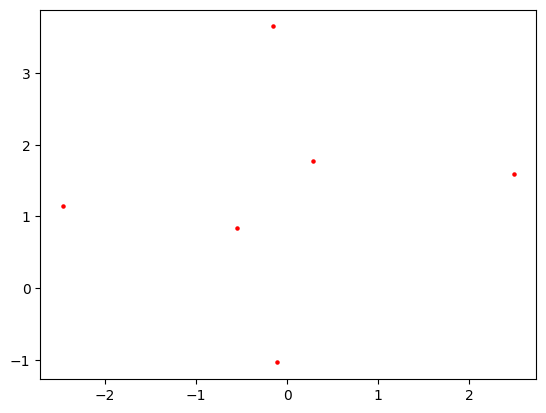

In [40]:
E = 30
step = 0
while E > 0.15:
    positions, E, grads = evolve(positions, thetareq, distreq)
    if step%10 ==0:
        print(E)
    step = step + 1
plt.scatter(positions[:, 0], positions[:, 1], color = 'red', s = 5)
plt.show()

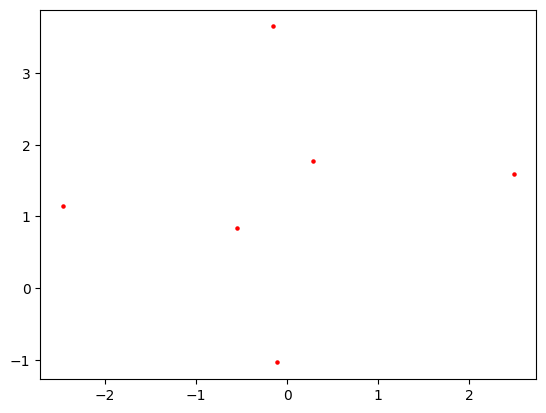

In [39]:
plt.scatter(positions[:, 0], positions[:, 1], color = 'red', s = 5)
plt.show()